In [1]:
import os
import sys
word_dir = '/Users/lxx/Documents/codes/st-missing-fill'
os.chdir(word_dir)
sys.path.append(word_dir)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from src.data.miss_pattern import mask_mcar, mask_seq, mask_spatial

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

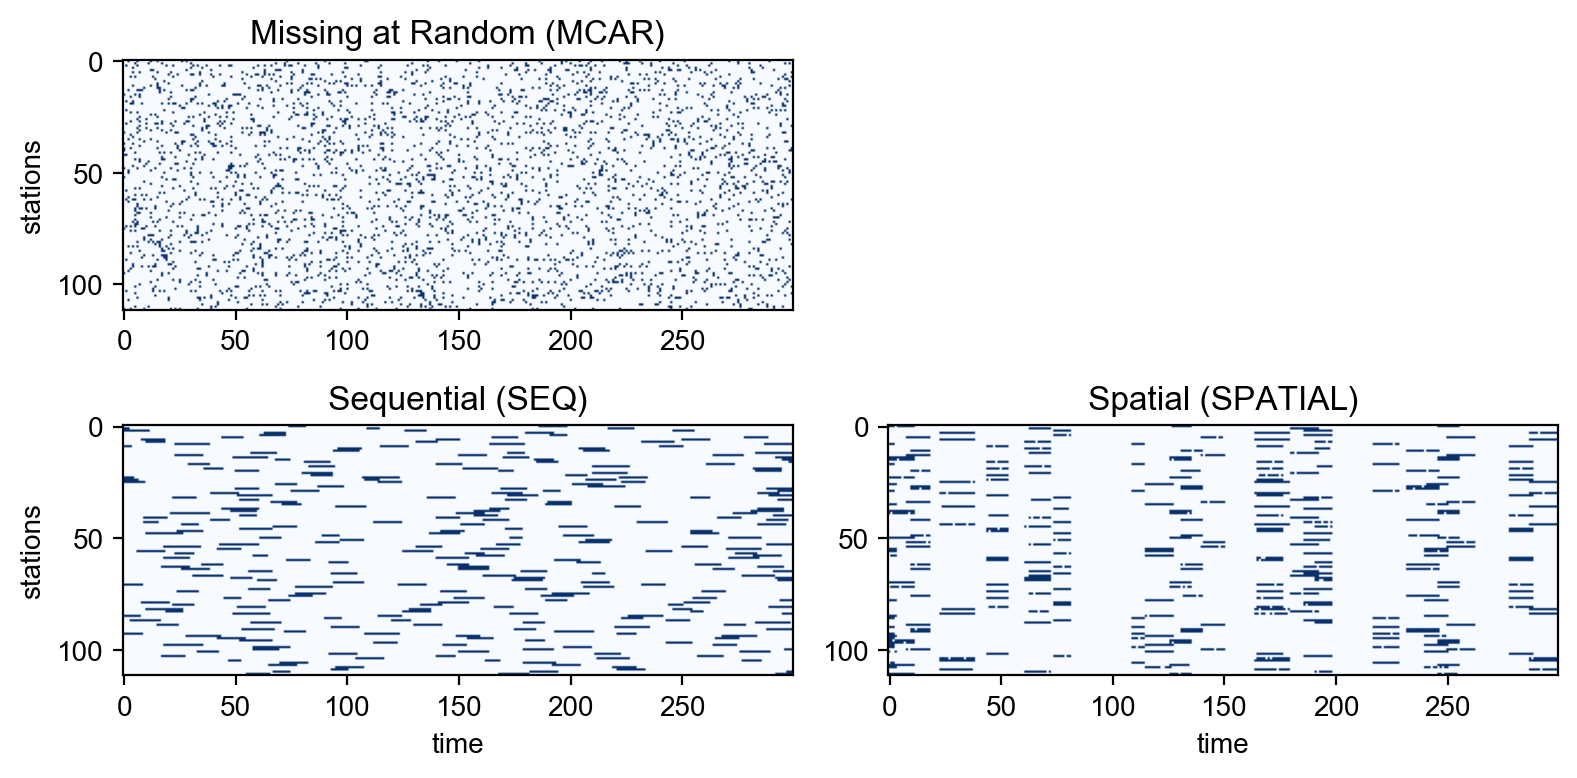

In [54]:
S_cluster = pd.read_csv('data/processed/all_stations.csv')['cluster'].tolist()

mask1 = mask_mcar() # mcar
mask2 = mask_seq() # seq
mask3 = mask_spatial(S_cluster=S_cluster) # spatial

# 3行1列 只有最后一个有x轴，叫time；y轴都有，叫stations，标题分别为mcar, seq, spatial
a, b = 3500, 3800
plt.figure(figsize=(8, 4))
plt.subplot(2, 2, 1)
plt.imshow(mask1[:, a:b], cmap='Blues')   # 更柔和的灰度
plt.title('Missing at Random (MCAR)')
plt.ylabel('stations')
plt.subplot(2, 2, 3)
plt.imshow(mask2[:, a:b], cmap='Blues')
plt.title('Sequential (SEQ)')
plt.xlabel('time')
plt.ylabel('stations')
plt.subplot(2, 2, 4)
plt.imshow(mask3[:, a:b], cmap='Blues')
plt.title('Spatial (SPATIAL)')
plt.xlabel('time')
plt.tight_layout()
plt.show()